In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

C:\Users\Lena\Promotion\neurolib\GUI\current\gui\data\01110
01110


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 4
limit = 40
i_range = range(0, limit,i_stepsize)
i_range_0 = range(0, limit,i_stepsize)
i_range_1 = range(0, limit,i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
-------  8 0.47500000000000014 0.40000000000000013
-------  12 0.47500000000000014 0.42500000000000016
-------  16 0.47500000000000014 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003


In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.2666253313
Gradient descend method:  None
RUN  0 , total integrated cost =  13602.2666253313
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  12 0.47500000000000014 0.4250000000000001

In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.2666253313
Gradient descend method:  None
RUN  1 , total integrated cost =  185.1659945384979
RUN  2 , total integrated cost =  49.6738209340149
RUN  3 , total integrated cost =  48.79989802374887
RUN  4 , total integrated cost =  48.79975033881013
RUN  5 , total integrated cost =  48.799554694572535
RUN  6 , total integrated cost =  48.795896746966456
RUN  7 , total integrated cost =  48.7801380917198
RUN  8 , total integrated cost =  48.7781974343969
RUN  9 , total integrated cost =  48.77799688428564
RUN  10 , total integrated cost =  48.7778419639474
RUN  11 , total integrated cost =  48.776772112304364
RUN  12 , total integrated cost =  48.7569160992744
RUN  13 , total integrated cost =  48.75040406317838
RUN  14 , total integrated cost =  48.750188444150695
RUN  15 , total int

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  93 , total integrated cost =  1.7263852156690895
Improved over  93  iterations in  466.06759079999995  seconds by  99.98730810633829  percent.
Problem in initial value trasfer:  Vmean_exc -56.67607344969904 -56.67607296737406
weight =  78790.44897902184
set cost params:  1.0 78790.44897902184 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13367.207978060644
Gradient descend method:  None
RUN  1 , total integrated cost =  11887.74693825827
RUN  2 , total integrated cost =  11877.413273727498
RUN  3 , total integrated cost =  11876.977868415079
RUN  4 , total integrated cost =  11876.008419044332
RUN  5 , total integrated cost =  11837.326673108757
RUN  6 , total integrated cost =  11817.16961284051
RUN  7 , total integrated cost =  11817.061815826883
RUN  8 , total integrated cost =  11816.996883388121
RUN  9 , total integrated cost =  11816.880852779357
RUN  10 , total integrated cost =  11815.54682749762
RUN  11 , tota

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  11785.040835532416
Control only changes marginally.
RUN  51 , total integrated cost =  11785.040835532416
Improved over  51  iterations in  6.358077900000012  seconds by  11.836182582967297  percent.
Problem in initial value trasfer:  Vmean_exc -56.67577627444439 -56.67578367184155
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  41.08020814986787
RUN  2 , total integrated cost =  35.28016047760578
RUN  3 , total integrated cost =  11.643080054934469
RUN  4 , total integrated cost =  11.257401603570573
RUN  5 , total integrated cost =  10.755471130228857
RUN  6 , total integrated cost =  10.472200939306978
RUN  7 , total integrated cost =  9.785981822897476
RUN  8 , total integrated cost =  9.275937554398773
RUN  9 , total integrated cost =  7.9235452151496855
RUN  

...

RUN  1 , total integrated cost =  16568.217666681165
Control only changes marginally.
RUN  1 , total integrated cost =  16568.217666681165
Improved over  1  iterations in  0.3257499999999709  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -71.58590466470297 -71.58596066513002
-------  36 0.4250000000000001 0.5500000000000003
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7741.667733280556
Gradient descend method:  None
RUN  1 , total integrated cost =  7741.667733280515
RUN  2 , total integrated cost =  7741.667733280514


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  7741.667733280514
Control only changes marginally.
RUN  3 , total integrated cost =  7741.667733280514
Improved over  3  iterations in  0.5348819000000731  seconds by  5.400124791776761e-13  percent.
Problem in initial value trasfer:  Vmean_exc -77.76264310030122 -77.76264311799103
weight =  10.000000000000053
set cost params:  1.0 10.000000000000053 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7741.667733280514
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7741.667733280514
Control only changes marginally.
RUN  1 , total integrated cost =  7741.667733280514
Improved over  1  iterations in  0.387179700000047  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -77.76264310030122 -77.76264311799103


In [15]:
"""
#plot initial guesses
for i in i_range:
    print("---------", i)
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()
"""

'\n#plot initial guesses\nfor i in i_range:\n    print("---------", i)\n        \n    aln.params.mue_ext_mean = exc[i] * 5.\n    aln.params.mui_ext_mean = inh[i] * 5.\n\n    plotFunc.plot_control_current(aln, [bestControl_init[i]],\n        [costnode_init[i]], [weights_init[i]], dur,\n        dur_pre, dur_post, initVars[i], target[i], \'\', filename_ = \'\', transition_time_ = trans_time,\n        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)\n    plt.show()\n'

In [16]:
found_solution = []
no_solution = []
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break


    for i in i_range:
        print("------- ", i, exc[i], inh[i])        

        if np.abs(np.mean(bestState_init[i][0,0,-300:]) - target[i][0,0,-1]) < 0.1 * np.abs(
            np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
            np.mean(bestState_init[i][0,1,-300:]) - target[i][0,1,-1]) < 0.1 * np.abs(
            np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amax(
            bestState_init[i][0,0,:]) < target[i][0,0,-1] + 1. and np.amax(
            bestState_init[i][0,1,:]) < target[i][0,1,-1] + 1.:
            # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
            #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        if len(found_solution) == 0:
            continue
            
        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)

------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  4 0.4500000000000001 0.3750000000000001
found solution for  4
-------  8 0.47500000000000014 0.40000000000000013
found solution for  8
-------  12 0.47500000000000014 0.42500000000000016
found solution for  12
-------  16 0.47500000000000014 0.4500000000000002
found solution for  16
-------  20 0.4500000000000001 0.4750000000000002
found solution for  20
-------  24 0.4000000000000001 0.5000000000000002
[0, 4, 8, 12, 16, 20] []
closest index  20
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3042.6655157184023
Gradient descend method:  None
RUN  1 , total integrated cost =  2980.9961474625165
RUN  2 , total integrated cost =  2980.9816359356655
RUN  3 

ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  2980.98163239352
Control only changes marginally.
RUN  5 , total integrated cost =  2980.98163239352
Improved over  5  iterations in  1.1953059999999596  seconds by  2.0272975457283593  percent.
Problem in initial value trasfer:  Vmean_exc -77.68654861811618 -77.6865486376419
weight =  10.000000000000234
set cost params:  1.0 10.000000000000234 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2980.98163239352
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2980.98163239352
Control only changes marginally.
RUN  1 , total integrated cost =  2980.98163239352
Improved over  1  iterations in  0.34624110000004293  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -77.68654861811618 -77.6865486376419
-------  28 0.5000000000000002 0.5000000000000002
found solution for  28
-------  32 0.47500000000000014 0.5250000000000002
[0, 4, 8, 12, 16, 20, 28] []
closest index  28
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16606.345081050975
Gradient descend method:  None
RUN  1 , total integrated cost =  16568.231673876526
RUN  2 , total integrated cost =  16568.217682502254
RUN  3 , total integrated cost =  16568.217666977776
RUN  4 , total integrated cost =  16568.21766697777


...

Control only changes marginally.
RUN  27 , total integrated cost =  7377.879985461487
Improved over  27  iterations in  2.5818607999999585  seconds by  3.8575575150952375  percent.
Problem in initial value trasfer:  Vmean_exc -56.63344041254621 -56.633473697359925
------------------------------------------------------------
-------------------- 3
------------------------------------------------------------
found solution:  [0, 4, 8, 12, 16, 20, 28, 32]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
-------  8 0.47500000000000014 0.40000000000000013
-------  12 0.47500000000000014 0.42500000000000016
-------  16 0.47500000000000014 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
[0, 4, 8, 12, 16, 20, 28, 32] [20, 16, 28]
closest index  32
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integra

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  72 , total integrated cost =  168.28382625446613
Improved over  72  iterations in  7.186721900000066  seconds by  94.5304258993337  percent.
Problem in initial value trasfer:  Vmean_exc -56.652226435076486 -56.652226059127784
weight =  177.14011493213698
set cost params:  1.0 177.14011493213698 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2979.2882096192943
Gradient descend method:  None
RUN  1 , total integrated cost =  2963.476154546873
RUN  2 , total integrated cost =  2963.476066709507
RUN  3 , total integrated cost =  2963.476055649001
RUN  4 , total integrated cost =  2963.4760537684697
RUN  5 , total integrated cost =  2963.4760534936972
RUN  6 , total integrated cost =  2963.476053449972
RUN  7 , total integrated cost =  2963.4760534437874
RUN  8 , total integrated cost =  2963.4760534426955
RUN  9 , total integrated cost =  2963.4760534425154
RUN  10 , total integrated cost =  2963.476053442493
RUN  11 , tota

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  2963.4760534424872
Control only changes marginally.
RUN  13 , total integrated cost =  2963.4760534424872
Improved over  13  iterations in  1.4162625999999818  seconds by  0.5307360370760392  percent.
Problem in initial value trasfer:  Vmean_exc -56.668805928953994 -56.66878769944369
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
found solution for  36
------------------------------------------------------------
-------------------- 4
------------------------------------------------------------
found solution:  [0, 4, 8, 12, 16, 20, 28, 32, 36]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
-------  8 0.47500000000000014 0.40000000000000013
-------  12 0.47500000000000014 0.42500000000000016
-------  16 0.47500000000000014 0.4500000000000002
-------  20 0.4500000000000001 0.47500000

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print("------------------------------------------------")
    print('-------------------------', counter)
    
    if counter > 20:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_init[i] == [True, True]:
            continue
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
                       
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
    counter += 1

------------------------------------------------
------------------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  11758.778823336454
set cost params:  1.0 11758.778823336454 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.90456448574
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5901.90456448574
Control only changes marginally.
RUN  1 , total integrated cost =  5901.90456448574
Improved over  1  iterations in  0.32441990000006626  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62628819994373 -56.62629883386906
converged for  0
-------  4 0.4500000000000001 0.3750000000000001
weight =  90938.75230963208
set cost params:  1.0 90938.75230963208 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13577.028272348743
Gradient descend method:  None
RUN  1 , total integrated cost =  13576.429001781771
RUN  2 , total integrated cost =  13576.38784172447
RUN  3 , total integrated cost =  13576.37942797306
RUN  4 , total integrated cost =  13576.37749045914
RUN  5 , total integrated cost =  13576.376889186724
RUN  6 , total integrated cost =  13576.37643418399
RUN  7 , total integrated cost =  13576.375922786166
RUN  8 , total integrated cost =  13576.375119602395
RUN  9 , total integra

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  47 , total integrated cost =  13554.351621401143
Improved over  47  iterations in  4.7307102999999415  seconds by  0.1670221972932353  percent.
Problem in initial value trasfer:  Vmean_exc -56.67575254144561 -56.67576056806241
no convergence
-------  8 0.47500000000000014 0.40000000000000013
weight =  157275.8150971217
set cost params:  1.0 157275.8150971217 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17460.286483195097
Gradient descend method:  None
RUN  1 , total integrated cost =  17452.146899755116
RUN  2 , total integrated cost =  17452.005160711244
RUN  3 , total integrated cost =  17451.988644004727
RUN  4 , total integrated cost =  17451.985898359624
RUN  5 , total integrated cost =  17451.98543362175
RUN  6 , total integrated cost =  17451.985171736218
RUN  7 , total integrated cost =  17451.985122824302
RUN  8 , total integrated cost =  17451.985111313985
RUN  9 , total integrated cost =  17451.985111105616

...

RUN  1 , total integrated cost =  21309.16029480852
Control only changes marginally.
RUN  1 , total integrated cost =  21309.16029480852
Improved over  1  iterations in  0.2798943000000236  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.697794648558784 -56.697796686320764
converged for  28
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
weight =  342.1675595564547
set cost params:  1.0 342.1675595564547 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7719.108293969664
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7719.108293969664
Control only changes marginally.
RUN  1 , total integrated cost =  7719.108293969664
Improved over  1  iterations in  0.3036481000000322  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.6333510908302 -56.63338543782572
converged for  36
------------------------------------------------
------------------------- 12
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.37500

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  21309.16029480852
Control only changes marginally.
RUN  1 , total integrated cost =  21309.16029480852
Improved over  1  iterations in  0.31317349999994804  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.697794648558784 -56.697796686320764
converged for  28
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
------------------------------------------------
------------------------- 13
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, Tru

In [18]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [19]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  18345.524661437765
set cost params:  1.0 18345.524661437765 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.084761278668
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5902.084761278668
Control only changes marginally.
RUN  1 , total integrated cost =  5902.084761278668
Improved over  1  iterations in  0.8302509999999756  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62660952530909 -56.62661614032183
converged for  0
-------  4 0.4500000000000001 0.3750000000000001
weight =  91263.55143009189
set cost params:  1.0 91263.55143009189 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.1175831631
Gradient descend method:  None
RUN  1 , total integrated cost =  13075.163894549567
RUN  2 , total integrated cost =  10521.835982533767
RUN  3 , total integrated cost =  8036.256337554359
RUN  4 , total integrated cost =  7447.1001602968345
RUN  5 , total integrated cost =  7413.656966458744
RUN  6 , total integrated cost =  7403.964901918914
RUN  7 , total integrated cost =  7403.964901918904
RUN  8 , total integrated cost =  7403.964901918902
State only changes margi

ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  7403.9649019189
Control only changes marginally.
RUN  10 , total integrated cost =  7403.9649019189
Improved over  10  iterations in  4.626003499999911  seconds by  45.567556987717595  percent.
Problem in initial value trasfer:  Vmean_exc -56.67584543109246 -56.675850976702684
converged for  4
-------  8 0.47500000000000014 0.40000000000000013
weight =  158192.66102786016
set cost params:  1.0 158192.66102786016 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.036875788748
Gradient descend method:  None
RUN  1 , total integrated cost =  16775.74913552191
RUN  2 , total integrated cost =  13273.282452226054
RUN  3 , total integrated cost =  10275.371426638394
RUN  4 , total integrated cost =  8270.160047514808
RUN  5 , total integrated cost =  8255.786599144705
RUN  6 , total integrated cost =  8244.940080808059
RUN  7 , total integrated cost =  8244.800901975374
RUN  8 , total integrated cost =  8235.966812722916
RUN  

...

RUN  2 , total integrated cost =  16562.38085601901
Control only changes marginally.
RUN  2 , total integrated cost =  16562.38085601901
Improved over  2  iterations in  1.6787153999998736  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.68566358693443 -56.68566238658334
no convergence
-------  36 0.4250000000000001 0.5500000000000003
--------------- 11
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  16562.380856019012
Control only changes marginally.
RUN  1 , total integrated cost =  16562.380856019012
Improved over  1  iterations in  0.8951809000000139  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68566358693443 -56.68566238658334
no convergence
-------  36 0.4250000000000001 0.5500000000000003
--------------- 12
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.37500000000000

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  16562.38085601901
Control only changes marginally.
RUN  1 , total integrated cost =  16562.38085601901
Improved over  1  iterations in  1.2630047000000104  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68566358693443 -56.68566238658334
converged for  32
-------  36 0.4250000000000001 0.5500000000000003
--------------- 13
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
full convergence


In [20]:
"""
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
"""

'\nfor i in i_range_0:\n    \n    aln.params.mue_ext_mean = exc[i] * 5.\n    aln.params.mui_ext_mean = inh[i] * 5.\n\n    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],\n        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,\n        dur_pre, dur_post, initVars[i], target[i], \'\', filename_ = \'\', transition_time_ = trans_time,\n        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)\n'

In [21]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [22]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.37070350472151187
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.37070350472151187
Control only changes marginally.
RUN  1 , total integrated cost =  0.37070350472151187
Improved over  1  iterations in  0.4157549999999901  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.627621976793236 -56.62762179037296
converged for  0
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  195.43906008957592
Gradient descend method:  None
RUN  1 , total integrated cost =  0.10011709500901318
RUN  2 , total integrated cost =  0.09966042716946213
RUN  3 , total integrated cost =  0.09903953804189877
RUN  4 , total integrated cost =  0.0988005705739256
RUN  5 , total integrated cost =  0.09785431233504402
RUN  6 , total integrated cost =  0.09755240107111343
RUN  7 , total integrated cost =  0.09751777485494306
RUN  8 , total integrated cost =  0.09734233682203804
RUN  9 , total integrated cost =  0.09728275493

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  0.09597275693429191
Control only changes marginally.
RUN  30 , total integrated cost =  0.09597275693429191
Improved over  30  iterations in  4.869758600000068  seconds by  99.9508937686815  percent.
Problem in initial value trasfer:  Vmean_exc -56.676059195384546 -56.676059102365336
no convergence
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  538.6559169542228
Gradient descend method:  None
RUN  1 , total integrated cost =  0.07186245535450862
RUN  2 , total integrated cost =  0.07134243503640174
RUN  3 , total integrated cost =  0.06981465490957202
RUN  4 , total integrated cost =  0.06951898877071461
RUN  5 , total integrated cost =  0.06930819173755848
RUN  6 , total integrated cost =  0.06929755973861512
RUN  7 , total integrated cost =  0.06928768735466978
RUN  8 , total integrated cost =  0.06907091777655691
RUN  9 , total integrated cost 

...

RUN  1 , total integrated cost =  2.4477662965908813
Control only changes marginally.
RUN  1 , total integrated cost =  2.4477662965908813
Improved over  1  iterations in  0.36849530000017694  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69784727467574 -56.697847536783534
converged for  28
-------  32 0.47500000000000014 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8.323468100631773
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  8.323468100631773
Control only changes marginally.
RUN  1 , total integrated cost =  8.323468100631773
Improved over  1  iterations in  0.3856051000000207  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.6855896254316 -56.68559307973901
converged for  32
-------  36 0.4250000000000001 0.5500000000000003
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20.660900891078587
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  20.660900891078587
Control only changes marginally.
RUN  1 , total integrated cost =  20.660900891078587
Improved over  1  iterations in  0.3309942000000774  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.63708435307626 -56.637069322522976
converged for  36
--------------- 3
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
full convergence


----------- 0


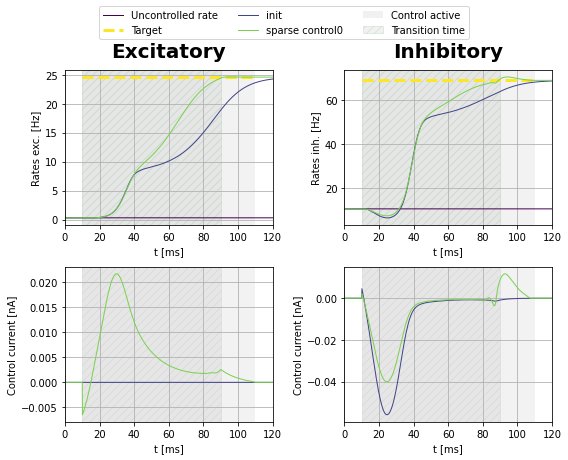

----------- 4


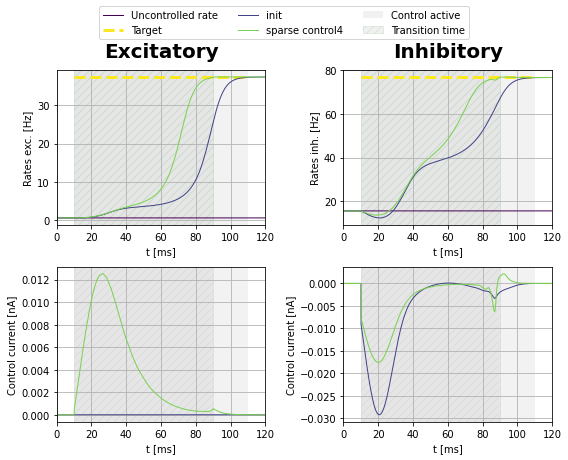

----------- 8


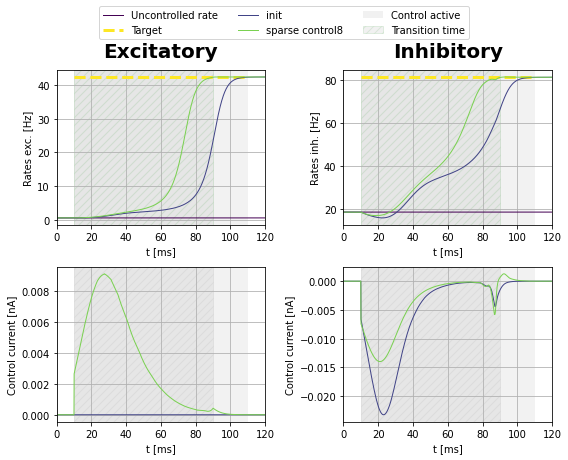

----------- 12


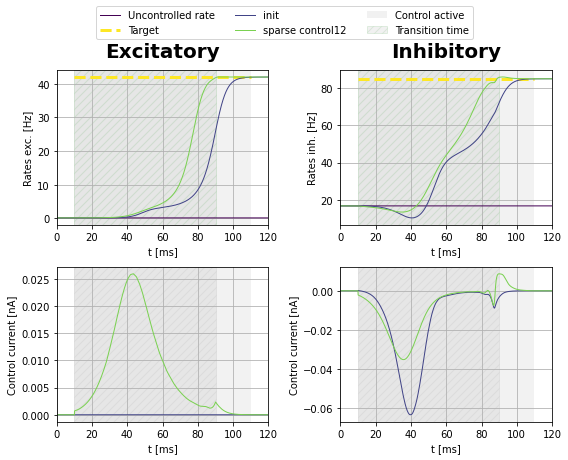

----------- 16


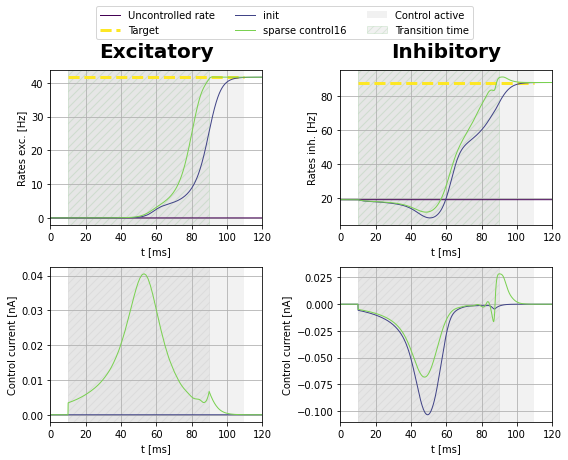

----------- 20


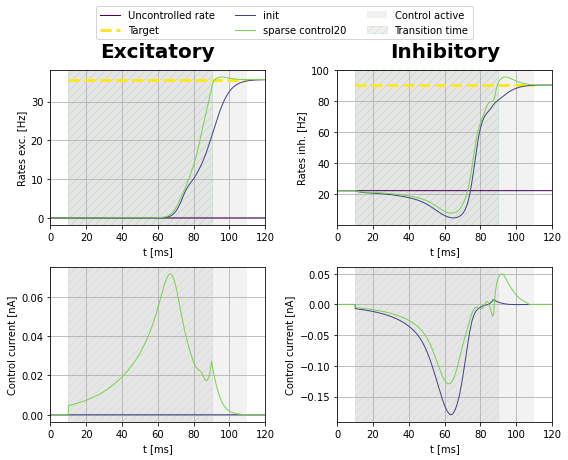

----------- 24


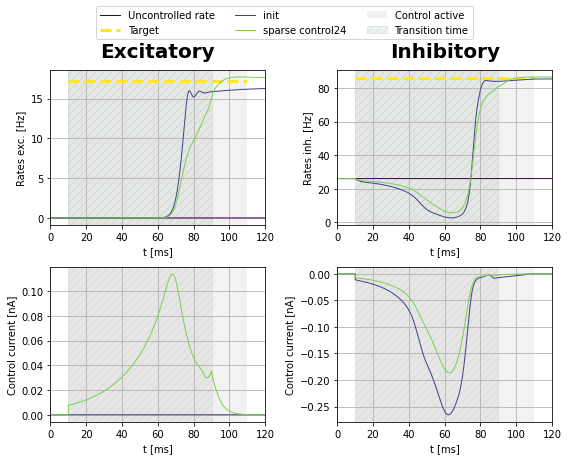

----------- 28


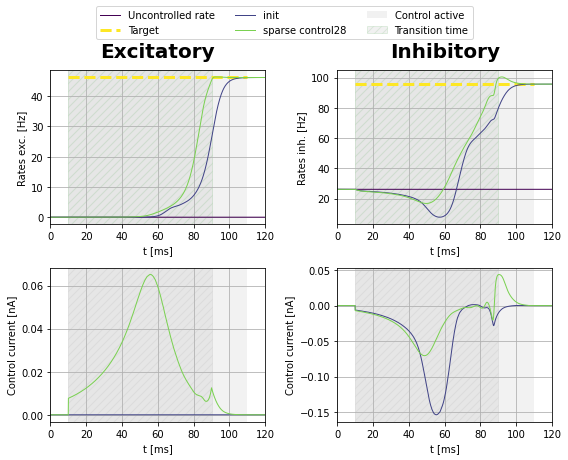

----------- 32


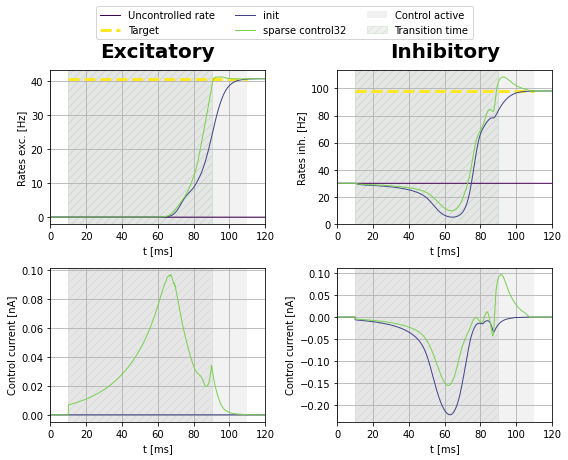

----------- 36


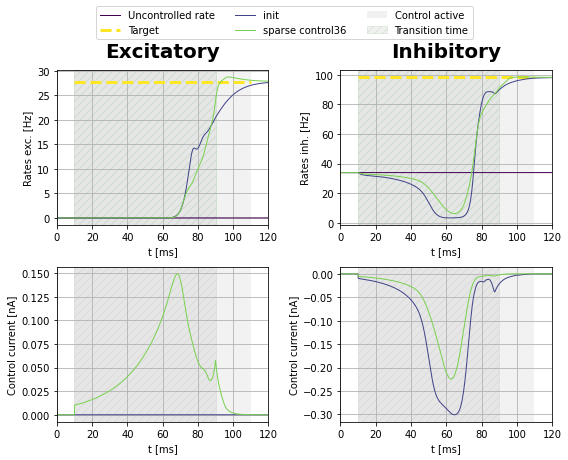

In [23]:
for i in i_range_1:
    
    print('-----------', i)
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_1[i]],
        [costnode_init[i], costnode_1[i]], [weights_init[i], weights_1[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()